# Personalized Artwork A/B Test — a Netflix-style experiment analysis

> **Data disclaimer:** every number in this notebook comes from **simulated data** (`generate_data.py`, seed 42).
> It is *not* Netflix data, and the effect sizes are my own assumptions, chosen to show common real-world
> patterns (novelty effects, segment differences, guardrail trade-offs). Netflix has written publicly about
> personalising artwork, which inspired the scenario, but none of its results are reproduced here.

**Business question:** Should the homepage show each member a *personalized* thumbnail for every title
(based on their viewing history) rather than a single default image?

| | |
|---|---|
| **Hypothesis** | Personalized artwork helps members find something they want to watch, increasing streaming hours. |
| **Unit / split** | Member account, 50/50 random assignment |
| **Duration** | 28 days (four full weekly cycles) |
| **Primary metric** | Streaming hours per member over 28 days |
| **Secondary metrics** | Play-start rate (play starts ÷ homepage sessions); 28-day cancellation rate |
| **Guardrails** (non-inferiority) | Playback error rate must not rise by more than 10% relative; homepage load time must not rise by more than 50 ms |
| **Decision rule (set before launch)** | Ship if the primary metric is significantly positive (α = 0.05, two-sided) **and** no guardrail is breached. |

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
C_CTRL, C_TRT = "#8a8f98", "#d6402b"
rng = np.random.default_rng(7)

# keep_default_na=False: otherwise pandas silently reads region "NA" (North America) as missing
members = pd.read_csv("data/members.csv", keep_default_na=False, na_values=[""])
assert members.region.isna().sum() == 0
daily = pd.read_csv("data/daily_by_arm.csv")
ctrl = members[members.variant == "control"]
trt = members[members.variant == "treatment"]
RESULTS = {}  # everything the dashboard needs is collected here
members.head()

,member_id,variant,tenure_segment,primary_device,region,plan,pre_hours_28d,hours_28d,sessions,play_starts,playback_errors,homepage_load_ms,cancelled,cancel_day
0,1,treatment,tenured,tv,NA,standard,39.192,22.574,28,21,0,894.1,0,NaN
1,2,control,new,mobile,LATAM,premium,32.968,25.968,37,21,0,672.7,0,NaN
2,3,treatment,tenured,tv,EMEA,basic,48.422,23.096,27,23,2,1093.1,0,NaN
3,4,treatment,tenured,tv,NA,premium,46.521,80.546,41,34,1,810.6,0,NaN
4,5,control,tenured,tv,LATAM,standard,11.919,28.891,42,28,0,868.5,0,NaN


## 1. Power analysis (done *before* the test)
Using the pre-period distribution of streaming hours, how many members per arm do we need to detect a
2% relative lift with 80% power? In practice this step decides how long the test runs.

In [2]:
mu, sd = members.pre_hours_28d.mean(), members.pre_hours_28d.std()
power = TTestIndPower()
rows = []
for mde in [0.01, 0.02, 0.03, 0.05]:
    d = (mu * mde) / sd
    rows.append({"relative_MDE": f"{mde:.0%}", "members_per_arm": int(np.ceil(power.solve_power(d, alpha=0.05, power=0.8)))})
power_table = pd.DataFrame(rows)
n_arm = len(members) / 2
achievable = power.solve_power(nobs1=n_arm, alpha=0.05, power=0.8) * sd / mu
print(f"pre-period mean = {mu:.1f} h, sd = {sd:.1f} h (coefficient of variation {sd/mu:.2f})")
print(f"With ~{n_arm:,.0f} members per arm, the minimum detectable effect is ≈ {achievable:.2%} (without CUPED)")
RESULTS["power"] = {"mde_no_cuped": achievable, "n_per_arm": n_arm, "table": rows}
power_table

pre-period mean = 34.4 h, sd = 36.6 h (coefficient of variation 1.07)
With ~40,000 members per arm, the minimum detectable effect is ≈ 2.11% (without CUPED)


,relative_MDE,members_per_arm
0,1%,178172
1,2%,44544
2,3%,19798
3,5%,7128


Viewing time is very skewed (the sd is larger than the mean), which is why streaming-hour tests need
tens of thousands of members per arm. CUPED (Section 4) lowers this requirement.

## 2. Sanity checks — run these before looking at any results

In [3]:
# 2a. Sample ratio mismatch (SRM): did randomisation produce the expected 50/50 split?
counts = members.variant.value_counts().reindex(["control", "treatment"])
chi2, p_srm = stats.chisquare(counts, f_exp=[len(members) / 2] * 2)
print(counts.to_dict(), f"chi2 = {chi2:.2f}, p = {p_srm:.4f}")
print("SRM check:", "PASS" if p_srm > 0.001 else "FAIL — stop and debug assignment")

# 2b. Pre-period balance (a 'retro A/A'): arms should not differ before treatment started
t_pre, p_pre = stats.ttest_ind(trt.pre_hours_28d, ctrl.pre_hours_28d, equal_var=False)
print(f"Pre-period hours: control {ctrl.pre_hours_28d.mean():.2f} vs treatment {trt.pre_hours_28d.mean():.2f}, p = {p_pre:.3f}")

# 2c. Covariate balance
bal = pd.concat({c: members.groupby("variant")[c].value_counts(normalize=True).unstack(0)
                 for c in ["tenure_segment", "primary_device", "region", "plan"]})
RESULTS["sanity"] = {"control_n": int(counts["control"]), "treatment_n": int(counts["treatment"]),
                     "srm_p": p_srm, "pre_period_p": p_pre}
bal.style.format("{:.1%}")

{'control': 39743, 'treatment': 40257} chi2 = 3.30, p = 0.0692
SRM check: PASS
Pre-period hours: control 34.28 vs treatment 34.46, p = 0.502


The split is 49.7 / 50.3. A chi-square p-value of about 0.07 is above the usual SRM alarm threshold
(p < 0.001), so randomisation looks fine. Pre-period viewing and the covariate mix are balanced.

## 3. Primary metric — streaming hours per member

In [4]:
def rel_lift(y_t, y_c):
    """Relative lift of means, with a delta-method 95% CI and a Welch t-test p-value."""
    mt, mc = y_t.mean(), y_c.mean()
    vt, vc = y_t.var(ddof=1) / len(y_t), y_c.var(ddof=1) / len(y_c)
    lift = mt / mc - 1
    se = np.sqrt(vt / mc**2 + (mt**2) * vc / mc**4)
    p = stats.ttest_ind(y_t, y_c, equal_var=False).pvalue
    return {"control": mc, "treatment": mt, "lift": lift,
            "ci_low": lift - 1.96 * se, "ci_high": lift + 1.96 * se, "p": p, "se": se}

primary = rel_lift(trt.hours_28d.values, ctrl.hours_28d.values)
pd.Series(primary).round(4)

control      33.8884
treatment    34.9519
lift          0.0314
ci_low        0.0173
ci_high       0.0454
p             0.0000
se            0.0072
dtype: float64

Delta-method CI: [1.73%, 4.54%]
Bootstrap CI   : [1.79%, 4.54%]  — they agree, so the normal approximation holds at this n


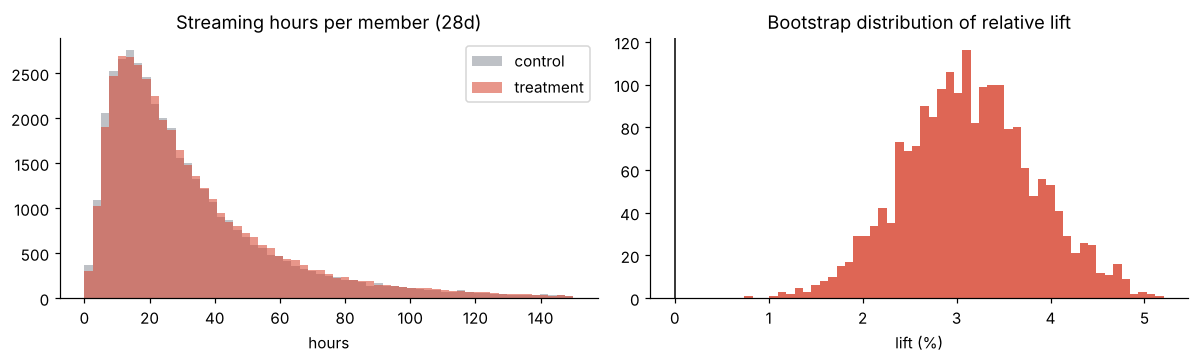

In [5]:
# Bootstrap check: makes no normality assumption, which matters for skewed metrics
yt, yc = trt.hours_28d.values, ctrl.hours_28d.values
boot = np.empty(2000)
for i in range(2000):
    boot[i] = rng.choice(yt, len(yt)).mean() / rng.choice(yc, len(yc)).mean() - 1
b_lo, b_hi = np.percentile(boot, [2.5, 97.5])
print(f"Delta-method CI: [{primary['ci_low']:.2%}, {primary['ci_high']:.2%}]")
print(f"Bootstrap CI   : [{b_lo:.2%}, {b_hi:.2%}]  — they agree, so the normal approximation holds at this n")
primary.update({"boot_low": b_lo, "boot_high": b_hi})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
bins = np.linspace(0, 150, 60)
ax[0].hist(yc, bins, alpha=.55, color=C_CTRL, label="control"); ax[0].hist(yt, bins, alpha=.55, color=C_TRT, label="treatment")
ax[0].set(title="Streaming hours per member (28d)", xlabel="hours"); ax[0].legend()
ax[1].hist(boot * 100, 50, color=C_TRT, alpha=.8); ax[1].axvline(0, color="k", lw=1)
ax[1].set(title="Bootstrap distribution of relative lift", xlabel="lift (%)")
plt.tight_layout()

## 4. Variance reduction with CUPED
CUPED (Controlled-experiment Using Pre-Experiment Data) removes the part of each member's outcome that
their *pre-period* behaviour already predicts. Because assignment is random, this leaves the expected
treatment effect unchanged but shrinks the variance, giving a tighter CI from the same sample.

In [6]:
X, Y = members.pre_hours_28d.values, members.hours_28d.values
theta = np.cov(X, Y)[0, 1] / X.var(ddof=1)
members["hours_cuped"] = Y - theta * (X - X.mean())
ctrl, trt = members[members.variant == "control"], members[members.variant == "treatment"]

# Express as a lift on the original scale: adjusted difference / unadjusted control mean
def cuped_lift(t, c, col="hours_cuped", base="hours_28d"):
    diff = t[col].mean() - c[col].mean()
    se = np.sqrt(t[col].var(ddof=1) / len(t) + c[col].var(ddof=1) / len(c))
    mc = c[base].mean()
    return {"lift": diff / mc, "ci_low": (diff - 1.96 * se) / mc, "ci_high": (diff + 1.96 * se) / mc,
            "p": 2 * stats.norm.sf(abs(diff / se)), "se": se / mc, "abs_diff_hours": diff}

cuped = cuped_lift(trt, ctrl)
var_red = 1 - members.hours_cuped.var() / members.hours_28d.var()
print(f"theta = {theta:.3f}; corr(pre, post) = {np.corrcoef(X, Y)[0,1]:.2f}; variance reduced by {var_red:.0%}")
print(f"Unadjusted: {primary['lift']:+.2%}  CI [{primary['ci_low']:+.2%}, {primary['ci_high']:+.2%}]  p={primary['p']:.2g}")
print(f"CUPED     : {cuped['lift']:+.2%}  CI [{cuped['ci_low']:+.2%}, {cuped['ci_high']:+.2%}]  p={cuped['p']:.2g}")
print(f"→ CI is {1 - cuped['se']/primary['se']:.0%} narrower; equivalent to ~{1/(1-var_red):.1f}x the sample size")
RESULTS["primary"] = {**primary, "metric": "Streaming hours / member (28d)"}
RESULTS["cuped"] = {**cuped, "variance_reduction": var_red, "theta": theta}

theta = 0.742; corr(pre, post) = 0.80; variance reduced by 65%
Unadjusted: +3.14%  CI [+1.73%, +4.54%]  p=8.6e-06
CUPED     : +2.76%  CI [+1.94%, +3.58%]  p=5e-11
→ CI is 41% narrower; equivalent to ~2.8x the sample size


The unadjusted and CUPED estimates are close, and that's what we should expect: CUPED changes the
*precision* of the estimate, not its direction. If they disagreed a lot, I would check the pre-period
balance before trusting either one.

## 5. Secondary metrics (with a multiple-testing correction)
**Play-start rate** is a *ratio metric*: the randomisation unit is the member, but the denominator is
sessions. Treating sessions as independent would understate the variance, so I use the delta method on
member-level sums instead.

In [7]:
def ratio_metric(df_t, df_c, num, den):
    def stats_(df):
        n, s_num, s_den = len(df), df[num].values, df[den].values
        r = s_num.sum() / s_den.sum()
        mu_d = s_den.mean()
        var = (s_num.var(ddof=1) - 2 * r * np.cov(s_num, s_den)[0, 1] + r**2 * s_den.var(ddof=1)) / (n * mu_d**2)
        return r, var
    rt, vt = stats_(df_t); rc, vc = stats_(df_c)
    diff, se = rt - rc, np.sqrt(vt + vc)
    return {"control": rc, "treatment": rt, "abs_diff": diff, "lift": rt / rc - 1,
            "ci_low": (diff - 1.96 * se) / rc, "ci_high": (diff + 1.96 * se) / rc,
            "p": 2 * stats.norm.sf(abs(diff / se))}

play = ratio_metric(trt, ctrl, "play_starts", "sessions")

# Cancellation: two-proportion z-test
pc, pt = ctrl.cancelled.mean(), trt.cancelled.mean()
se_c = np.sqrt(pc * (1 - pc) / len(ctrl) + pt * (1 - pt) / len(trt))
cancel = {"control": pc, "treatment": pt, "abs_diff": pt - pc, "lift": pt / pc - 1,
          "ci_low": (pt - pc - 1.96 * se_c) / pc, "ci_high": (pt - pc + 1.96 * se_c) / pc,
          "p": 2 * stats.norm.sf(abs((pt - pc) / se_c))}

# Holm correction across the secondary family
reject, p_adj, _, _ = multipletests([play["p"], cancel["p"]], alpha=0.05, method="holm")
play["p_holm"], cancel["p_holm"] = p_adj
sec = pd.DataFrame({"Play-start rate": play, "28-day cancellation": cancel}).T
RESULTS["secondary"] = {"play_start_rate": play, "cancellation": cancel}
sec[["control", "treatment", "lift", "ci_low", "ci_high", "p", "p_holm"]].style.format(
    {"control": "{:.4f}", "treatment": "{:.4f}", "lift": "{:+.2%}", "ci_low": "{:+.2%}", "ci_high": "{:+.2%}", "p": "{:.3g}", "p_holm": "{:.3g}"})

,control,treatment,lift,ci_low,ci_high,p,p_holm
Play-start rate,0.6201,0.6359,+2.56%,+2.29%,+2.83%,1.9e-77,3.79e-77
28-day cancellation,0.0320,0.0302,-5.55%,-13.07%,+1.97%,0.148,0.148


Play-start rate improves clearly, which supports the mechanism: members find something to play more often.
Cancellation is directionally lower, but its CI includes zero. A 28-day test with a ~3% base rate is
underpowered for retention, so I report it as **inconclusive**, not as "no effect".

## 6. Guardrails

In [8]:
err = ratio_metric(trt, ctrl, "playback_errors", "play_starts")
lt, lc = trt.homepage_load_ms, ctrl.homepage_load_ms
d_ms = lt.mean() - lc.mean()
se_ms = np.sqrt(lt.var() / len(lt) + lc.var() / len(lc))
MARGIN_MS = 50
load = {"control": lc.mean(), "treatment": lt.mean(), "abs_diff": d_ms,
        "ci_low_ms": d_ms - 1.96 * se_ms, "ci_high_ms": d_ms + 1.96 * se_ms,
        "upper_95_one_sided": d_ms + 1.645 * se_ms, "margin_ms": MARGIN_MS}
load["pass"] = bool(load["upper_95_one_sided"] < MARGIN_MS)   # non-inferiority test
ERR_MARGIN = 0.10                                               # max tolerated relative increase
err["upper_95_one_sided"] = err["lift"] + 1.645 * (err["ci_high"] - err["lift"]) / 1.96
err["margin_rel"] = ERR_MARGIN
err["pass"] = bool(err["upper_95_one_sided"] < ERR_MARGIN)

print(f"Playback error rate: {err['control']:.3%} → {err['treatment']:.3%} ({err['lift']:+.1%} relative, p = {err['p']:.2f}); "
      f"one-sided upper bound {err['upper_95_one_sided']:+.1%} < {ERR_MARGIN:.0%} margin → {'PASS' if err['pass'] else 'FAIL'}")
print(f"Homepage load: +{d_ms:.1f} ms, 95% CI [{load['ci_low_ms']:.1f}, {load['ci_high_ms']:.1f}] ms; "
      f"one-sided upper bound {load['upper_95_one_sided']:.1f} ms < {MARGIN_MS} ms margin → {'PASS' if load['pass'] else 'FAIL'}")
RESULTS["guardrails"] = {"playback_error_rate": err, "homepage_load_ms": load}

Playback error rate: 1.184% → 1.221% (+3.2% relative, p = 0.04); one-sided upper bound +5.7% < 10% margin → PASS
Homepage load: +15.2 ms, 95% CI [12.3, 18.2] ms; one-sided upper bound 17.7 ms < 50 ms margin → PASS


Both guardrails pass, but both deserve a mention:

- **Load time is significantly slower** (about +15 ms), but stays within the 50 ms tolerance agreed before
  launch. A guardrail is a limit agreed in advance, not a requirement that nothing gets worse.
- **Playback errors show a nominally significant increase** (p ≈ 0.04), yet the upper bound stays well inside
  the 10% margin. There's also no plausible mechanism (artwork doesn't touch the video player), and because
  this data is simulated I know the true effect is zero: **this is a false positive**. With many metrics
  tracked at α = 0.05, roughly 1 in 20 null metrics will look significant by chance. That's why guardrails
  are better framed as non-inferiority tests with margins than as "any significant change fails".

## 7. Who benefits? Segment analysis
CUPED-adjusted lift by segment. **Caveat:** cutting by 9 segments creates 9 more chances of a false
positive. I treat these results as hypotheses for follow-up, and I'd only act on a segment difference
that was planned in advance (tenure was) or that repeats in a second test.

New vs tenured lift difference: +4.51% (interaction p = 0.000)


,dimension,segment,n,lift,ci_low,ci_high,p
0,tenure_segment,new,"16,014",+6.60%,+4.71%,+8.50%,8.73e-12
1,tenure_segment,tenured,"63,986",+2.09%,+1.18%,+2.99%,5.98e-06
2,primary_device,mobile,"23,997",+1.99%,+0.50%,+3.48%,0.00879
3,primary_device,tv,"43,974",+3.13%,+2.03%,+4.23%,2.56e-08
4,primary_device,web,"12,029",+2.48%,+0.45%,+4.52%,0.0166
5,region,APAC,"20,083",+3.12%,+1.48%,+4.76%,0.000197
6,region,EMEA,"24,102",+1.97%,+0.44%,+3.50%,0.0117
7,region,LATAM,"11,855",+3.46%,+1.37%,+5.55%,0.00117
8,region,NA,"23,960",+2.91%,+1.42%,+4.40%,0.000123


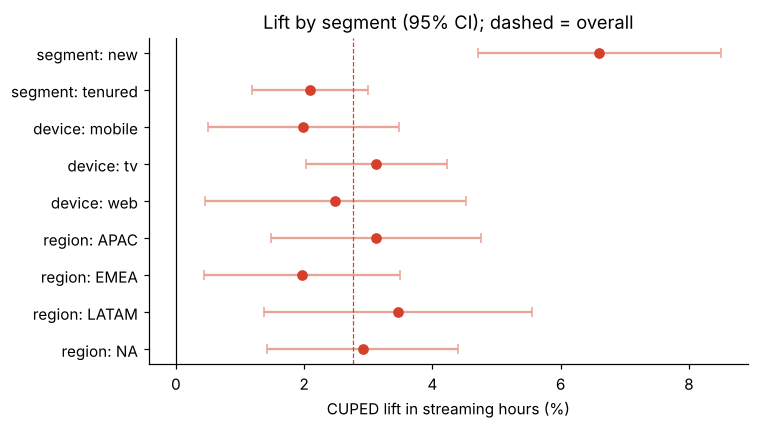

In [9]:
seg_rows = []
for dim in ["tenure_segment", "primary_device", "region"]:
    for val, g in members.groupby(dim):
        r = cuped_lift(g[g.variant == "treatment"], g[g.variant == "control"])
        seg_rows.append({"dimension": dim, "segment": val, "n": len(g), **{k: r[k] for k in ["lift", "ci_low", "ci_high", "p"]}})
seg = pd.DataFrame(seg_rows)

# Interaction test for the pre-registered split: is the new vs tenured difference real?
a, b = [cuped_lift(members[(members.tenure_segment == s) & (members.variant == "treatment")],
                   members[(members.tenure_segment == s) & (members.variant == "control")]) for s in ["new", "tenured"]]
z = (a["lift"] - b["lift"]) / np.sqrt(a["se"]**2 + b["se"]**2)
p_inter = 2 * stats.norm.sf(abs(z))
print(f"New vs tenured lift difference: {a['lift'] - b['lift']:+.2%} (interaction p = {p_inter:.3f})")

fig, ax = plt.subplots(figsize=(7, 4))
ypos = np.arange(len(seg))[::-1]
ax.errorbar(seg.lift * 100, ypos, xerr=[(seg.lift - seg.ci_low) * 100, (seg.ci_high - seg.lift) * 100],
            fmt="o", color=C_TRT, ecolor="#e9a397", capsize=3)
ax.axvline(0, color="k", lw=.8); ax.axvline(cuped["lift"] * 100, color=C_TRT, ls="--", lw=.8)
ax.set_yticks(ypos, [f"{d.split('_')[-1]}: {s}" for d, s in zip(seg.dimension, seg.segment)])
ax.set(xlabel="CUPED lift in streaming hours (%)", title="Lift by segment (95% CI); dashed = overall")
plt.tight_layout()
RESULTS["segments"] = seg_rows; RESULTS["tenure_interaction_p"] = p_inter
seg.style.format({"lift": "{:+.2%}", "ci_low": "{:+.2%}", "ci_high": "{:+.2%}", "p": "{:.3g}", "n": "{:,}"})

## 8. Is the effect lasting? Checking for a novelty effect
A new homepage look can get extra clicks at first simply because it's new. If the lift fades over the
test, the 28-day average **overstates** the long-run impact.

tenure_segment,new,tenured
week,,
1,+5.69%,+4.43%
2,+7.32%,+2.65%
3,+4.44%,+1.87%
4,+5.31%,+1.16%


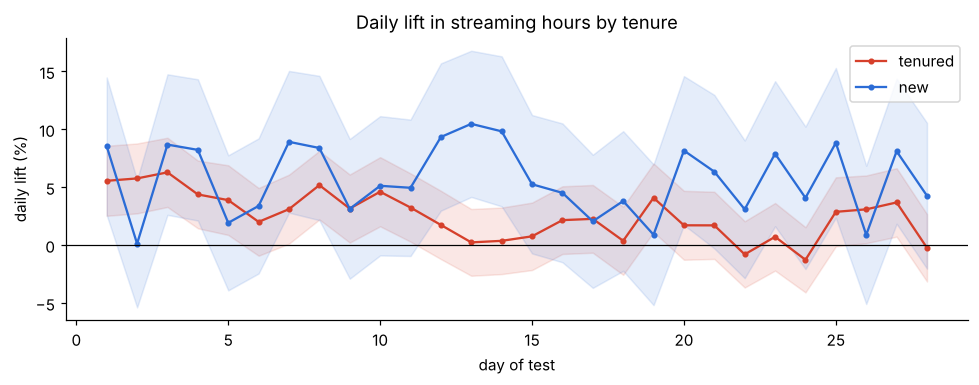

In [10]:
def daily_lift(df):
    out = []
    for (day, ten), g in df.groupby(["day", "tenure_segment"]):
        c, t = g[g.variant == "control"].iloc[0], g[g.variant == "treatment"].iloc[0]
        mc, mt = c.total_hours / c.active_members, t.total_hours / t.active_members
        vc = (c.sum_sq_hours / c.active_members - mc**2) / c.active_members
        vt = (t.sum_sq_hours / t.active_members - mt**2) / t.active_members
        se = np.sqrt(vt / mc**2 + mt**2 * vc / mc**4)
        out.append({"day": day, "tenure_segment": ten, "lift": mt / mc - 1, "se": se})
    return pd.DataFrame(out)

dl = daily_lift(daily)
dl["week"] = (dl.day - 1) // 7 + 1
weekly = dl.groupby(["tenure_segment", "week"]).lift.mean().unstack(0)

fig, ax = plt.subplots(figsize=(9, 3.6))
for ten, col in [("tenured", C_TRT), ("new", "#2b6cd6")]:
    s = dl[dl.tenure_segment == ten]
    ax.plot(s.day, s.lift * 100, "o-", ms=3, color=col, label=ten)
    ax.fill_between(s.day, (s.lift - 1.96 * s.se) * 100, (s.lift + 1.96 * s.se) * 100, color=col, alpha=.12)
ax.axhline(0, color="k", lw=.8); ax.set(xlabel="day of test", ylabel="daily lift (%)", title="Daily lift in streaming hours by tenure")
ax.legend(); plt.tight_layout()
RESULTS["daily_lift"] = dl.to_dict("records")
weekly.style.format("{:+.2%}")

In [11]:
# Estimate the 'settled' long-run effect from week 4 only, then blend by segment mix
mix = members.tenure_segment.value_counts(normalize=True)
wk4 = weekly.loc[4]
long_run = (wk4 * mix).sum()
print(f"Week-1 lift for tenured members: {weekly.loc[1, 'tenured']:+.2%} → week 4: {wk4['tenured']:+.2%}")
print(f"New members stay steady at about {weekly['new'].mean():+.2%}")
print(f"Blended week-4 (steady-state) estimate: {long_run:+.2%}  vs 28-day average {cuped['lift']:+.2%}")
RESULTS["novelty"] = {"weekly": weekly.reset_index().to_dict("records"), "long_run_estimate": long_run}

Week-1 lift for tenured members: +4.43% → week 4: +1.16%
New members stay steady at about +5.69%
Blended week-4 (steady-state) estimate: +1.99%  vs 28-day average +2.76%


## 9. Decision and recommendation

In [12]:
ship = (cuped["p"] < 0.05 and cuped["lift"] > 0 and err["pass"] and load["pass"])
RESULTS["decision"] = "SHIP" if ship else "DO NOT SHIP"
print("Decision rule met →", RESULTS["decision"])
with open("results.json", "w") as f:
    json.dump(RESULTS, f, default=lambda o: o.item() if hasattr(o, "item") else str(o), indent=1)

Decision rule met → SHIP


**Recommendation: ship personalized artwork, but report the long-run impact as smaller than the
headline number.**

- **Primary:** streaming hours rose significantly over 28 days, with or without CUPED.
- **Mechanism:** play-start rate rose too, consistent with members finding titles faster.
- **Guardrails:** both within their margins. Load time rose by about 15 ms (under the 50 ms margin); the small
  playback-error blip is a chance result well inside its 10% margin. I'd still flag load time to engineering
  as an optimisation target (e.g. pre-fetching artwork).
- **Novelty:** for tenured members (80% of the base), the lift fades from week 1 to week 4. The week-4 blended
  estimate is the more honest number to use in forecasts.
- **Segments:** new members benefit most. This supports prioritising personalisation in onboarding.
- **Retention:** inconclusive. I'd recommend a long-term holdout (e.g. 5% of members kept on default
  artwork for a quarter) to measure the effect on cancellations properly.

**Limitations:** simulated data; a 28-day window; member-level randomisation ignores shared household
profiles (possible interference); and the segment cuts are exploratory.